# Regrid GEOS C1440 fields to a regular lat-lon grid

In [11]:
import numpy as np
import xarray as xr
import pyresample
from datetime import timezone

import matplotlib.pyplot as plt
import numpy as np


import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_latlon_cartopy(
    da,
    time_index=0,
    vmin=None,
    vmax=None,
    cmap="viridis",
    title=None,
    figsize=(12, 6),
    cbar_label=None,
    projection=ccrs.PlateCarree(),
):
    """
    Cartopy-based lat-lon plot with coastlines.
    """

    if "time" in da.dims:
        da2 = da.isel(time=time_index)
    else:
        da2 = da

    fig = plt.figure(figsize=figsize,dpi=300)
    ax = plt.axes(projection=projection)

    im = ax.pcolormesh(
        da2["lon"],
        da2["lat"],
        da2,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_global()

    ax.set_title(title or da.name)

    cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02,shrink=0.7)
    if cbar_label:
        cbar.set_label(cbar_label)

    plt.tight_layout()
    return fig, ax



def plot_latlon(
    da,
    time_index=0,
    vmin=None,
    vmax=None,
    cmap="viridis",
    title=None,
    figsize=(10, 5),
    cbar_label=None,
):
    """
    Plot a lat-lon xarray DataArray produced by the regridder.

    Parameters
    ----------
    da : xr.DataArray
        Expected dims: (..., lat, lon)
    time_index : int
        Time index to plot if time dimension exists
    vmin, vmax : float
        Color limits
    cmap : str
        Matplotlib colormap
    title : str
        Plot title
    figsize : tuple
        Figure size in inches
    cbar_label : str
        Colorbar label
    """

    # Select time if present
    if "time" in da.dims:
        da2 = da.isel(time=time_index)
    else:
        da2 = da

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.pcolormesh(
        da2["lon"],
        da2["lat"],
        da2,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or da.name)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    if cbar_label:
        cbar.set_label(cbar_label)

    plt.tight_layout()
    return fig, ax



class GeoC1440_Unwrapped_Regridder:
    """
    Regrid GEOS C1440 fields stored on an "unwrapped" 2D grid (Ydim, Xdim)
    to a regular lat-lon grid using KDTree nearest-neighbor (fast & robust).

    Bridge file provides:
      lats(Ydim, Xdim), lons(Ydim, Xdim)
    """

    def __init__(
        self,
        lats_2d: np.ndarray,
        lons_2d: np.ndarray,
        lat_out: np.ndarray,
        lon_out: np.ndarray,
        radius_of_influence_m: float = 15e3,
        neighbours: int = 1,
        fill_value=np.nan,
        lon_wrap: str = "[-180,180]",
    ):
        # Normalize longitudes to match target convention
        lons = np.asarray(lons_2d)
        if lon_wrap == "[-180,180]":
            lons = ((lons + 180) % 360) - 180
        elif lon_wrap == "[0,360]":
            lons = lons % 360

        lats = np.asarray(lats_2d)

        self.lat_out = np.asarray(lat_out)
        self.lon_out = np.asarray(lon_out)
        self.radius = float(radius_of_influence_m)
        self.neighbours = int(neighbours)
        self.fill_value = fill_value

        # Source: point cloud
        self.src_def = pyresample.geometry.SwathDefinition(
            lons=lons.ravel(),
            lats=lats.ravel()
        )

        # Target: regular lat-lon grid
        lon2, lat2 = np.meshgrid(self.lon_out, self.lat_out)
        self.tgt_def = pyresample.geometry.GridDefinition(lons=lon2, lats=lat2)

        # Precompute neighbor mapping (expensive once, cheap thereafter)
        self.valid_in, self.valid_out, self.index_array, self.distance_array = \
            pyresample.kd_tree.get_neighbour_info(
                self.src_def,
                self.tgt_def,
                radius_of_influence=self.radius,
                neighbours=self.neighbours
            )

    @classmethod
    def from_latlon_file(
        cls,
        latlon_path: str,
        lat_name: str = "lats",
        lon_name: str = "lons",
        lat_out: np.ndarray = None,
        lon_out: np.ndarray = None,
        **kwargs
    ):
        if lat_out is None or lon_out is None:
            raise ValueError("Provide lat_out and lon_out arrays.")

        ds = xr.open_dataset(latlon_path)
        lats_2d = ds[lat_name].values
        lons_2d = ds[lon_name].values
        return cls(lats_2d=lats_2d, lons_2d=lons_2d, lat_out=lat_out, lon_out=lon_out, **kwargs)

    
    def _regrid_flat(self, flat_values: np.ndarray) -> np.ndarray:
        """flat_values shape: (lat*lon,)"""

        fn = pyresample.kd_tree.get_sample_from_neighbour_info

        # Newer pyresample signature (the one you have)
        try:
            return fn(
                "nn",                 # resample_type
                self.tgt_def.shape,   # output_shape
                flat_values,          # data
                self.valid_in,
                self.valid_out,
                self.index_array,
                self.distance_array,
                fill_value=self.fill_value,
            )
        except TypeError:
            # Older signature fallback (different releases)
            return fn(
                self.valid_in,
                self.valid_out,
                self.index_array,
                self.distance_array,
                flat_values,
                self.tgt_def.shape,
                fill_value=self.fill_value,
            )



    def regrid_dataarray(
        self,
        da: xr.DataArray,
        src_dims=("Ydim", "Xdim"),
        lat_name_out="lat",
        lon_name_out="lon",
    ) -> xr.DataArray:
        """
        Regrid an xarray DataArray that ends with (Ydim, Xdim),
        allowing any number of leading dims (time, lev, etc.).
        """
        missing = [d for d in src_dims if d not in da.dims]
        if missing:
            raise ValueError(f"Missing expected dims {missing}. Got {da.dims}")

        # put source dims at end
        lead_dims = [d for d in da.dims if d not in src_dims]
        da_t = da.transpose(*lead_dims, *src_dims)

        lead_shape = [da_t.sizes[d] for d in lead_dims]
        arr = da_t.values.reshape((*lead_shape, -1))  # (..., Ydim*Xdim)

        out_shape = (*lead_shape, len(self.lat_out), len(self.lon_out))
        out = np.full(out_shape, self.fill_value, dtype=arr.dtype)

        # iterate over leading dims
        it = np.ndindex(*lead_shape) if lead_shape else [()]
        for idx in it:
            vec = arr[idx] if lead_shape else arr
            out2d = self._regrid_flat(vec)
            if lead_shape:
                out[idx] = out2d
            else:
                out = out2d

        coords = {d: da_t.coords[d] for d in lead_dims if d in da_t.coords}
        coords[lat_name_out] = self.lat_out
        coords[lon_name_out] = self.lon_out

        dims = (*lead_dims, lat_name_out, lon_name_out)
        return xr.DataArray(out, coords=coords, dims=dims, name=da.name, attrs=da.attrs)


## Build a target grid

In [2]:
grid_ref = "/u/bura-z2/hectorg/COAS/data/grid_geos5/geos_c1440_lats_lons_2D.nc"


dx = 0.04
lat_out = np.arange(-90, 90.0001, dx)
lon_out = np.arange(-180, 180.0001, dx)

R = GeoC1440_Unwrapped_Regridder.from_latlon_file(
    grid_ref,
    lat_name="lats",
    lon_name="lons",
    lat_out=lat_out,
    lon_out=lon_out,
    radius_of_influence_m=20e3,   # tune: ~1–2 grid cells of your target
    neighbours=1,
    lon_wrap="[-180,180]",
)

## Regrid a variable from GEOS file

In [13]:
path = "/u/bura-z2/hectorg/COAS/data/geos/geosgcm_surf/geosgcm_surf/"

ds = xr.open_dataset(path+"DYAMOND_c1440_llc2160.geosgcm_surf.20200202_2130z.nc4")

display(ds)

# Example variable name (replace with what exists in geosgcm_surf)
da_cs = ds["T10M"]          # dims could be (time, Ydim, Xdim) or (Ydim, Xdim)

da_ll = R.regrid_dataarray(da_cs, src_dims=("lat","lon"))
# da_ll


<xarray.Dataset>
Dimensions:       (lon: 1440, lat: 8640, time: 1)
Coordinates:
  * lon           (lon) float64 305.0 305.1 305.1 305.2 ... 34.87 34.92 34.97
  * lat           (lat) float64 -35.25 -35.2 -35.15 ... -35.34 -35.31 -35.29
  * time          (time) datetime64[ns] 2020-02-02T21:30:00
Data variables: (12/64)
    ALBNF         (time, lat, lon) float32 ...
    ALBNR         (time, lat, lon) float32 ...
    ALBVF         (time, lat, lon) float32 ...
    ALBVR         (time, lat, lon) float32 ...
    ASNOW         (time, lat, lon) float32 ...
    BASEFLOW      (time, lat, lon) float32 ...
    ...            ...
    VS            (time, lat, lon) float32 ...
    WET1          (time, lat, lon) float32 ...
    WET2          (time, lat, lon) float32 ...
    WET3          (time, lat, lon) float32 ...
    Z0            (time, lat, lon) float32 ...
    Z0H           (time, lat, lon) float32 ...
Attributes:
    History:      File written by MAPL_CFIO
    Source:       Heracles-5_3
    Title:        DYAMOND_c1440_llc2160
    Contact:      http://gmao.gsfc.nasa.gov
    Conventions:  COARDS
    Institution:  NASA Global Modeling and Assimilation Office
    References:   http://gmao.gsfc.nasa.gov
    Comment:      DYAMOND_c1440_llc2160

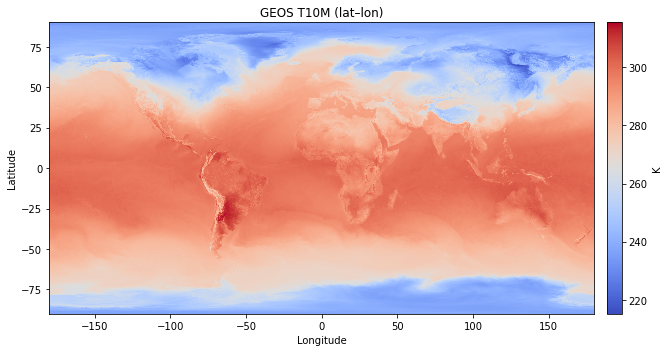

In [5]:
fig, ax = plot_latlon(
    da_ll,
    time_index=0,
    cmap="coolwarm",
    title="GEOS T10M (lat–lon)",
    cbar_label="K",
)


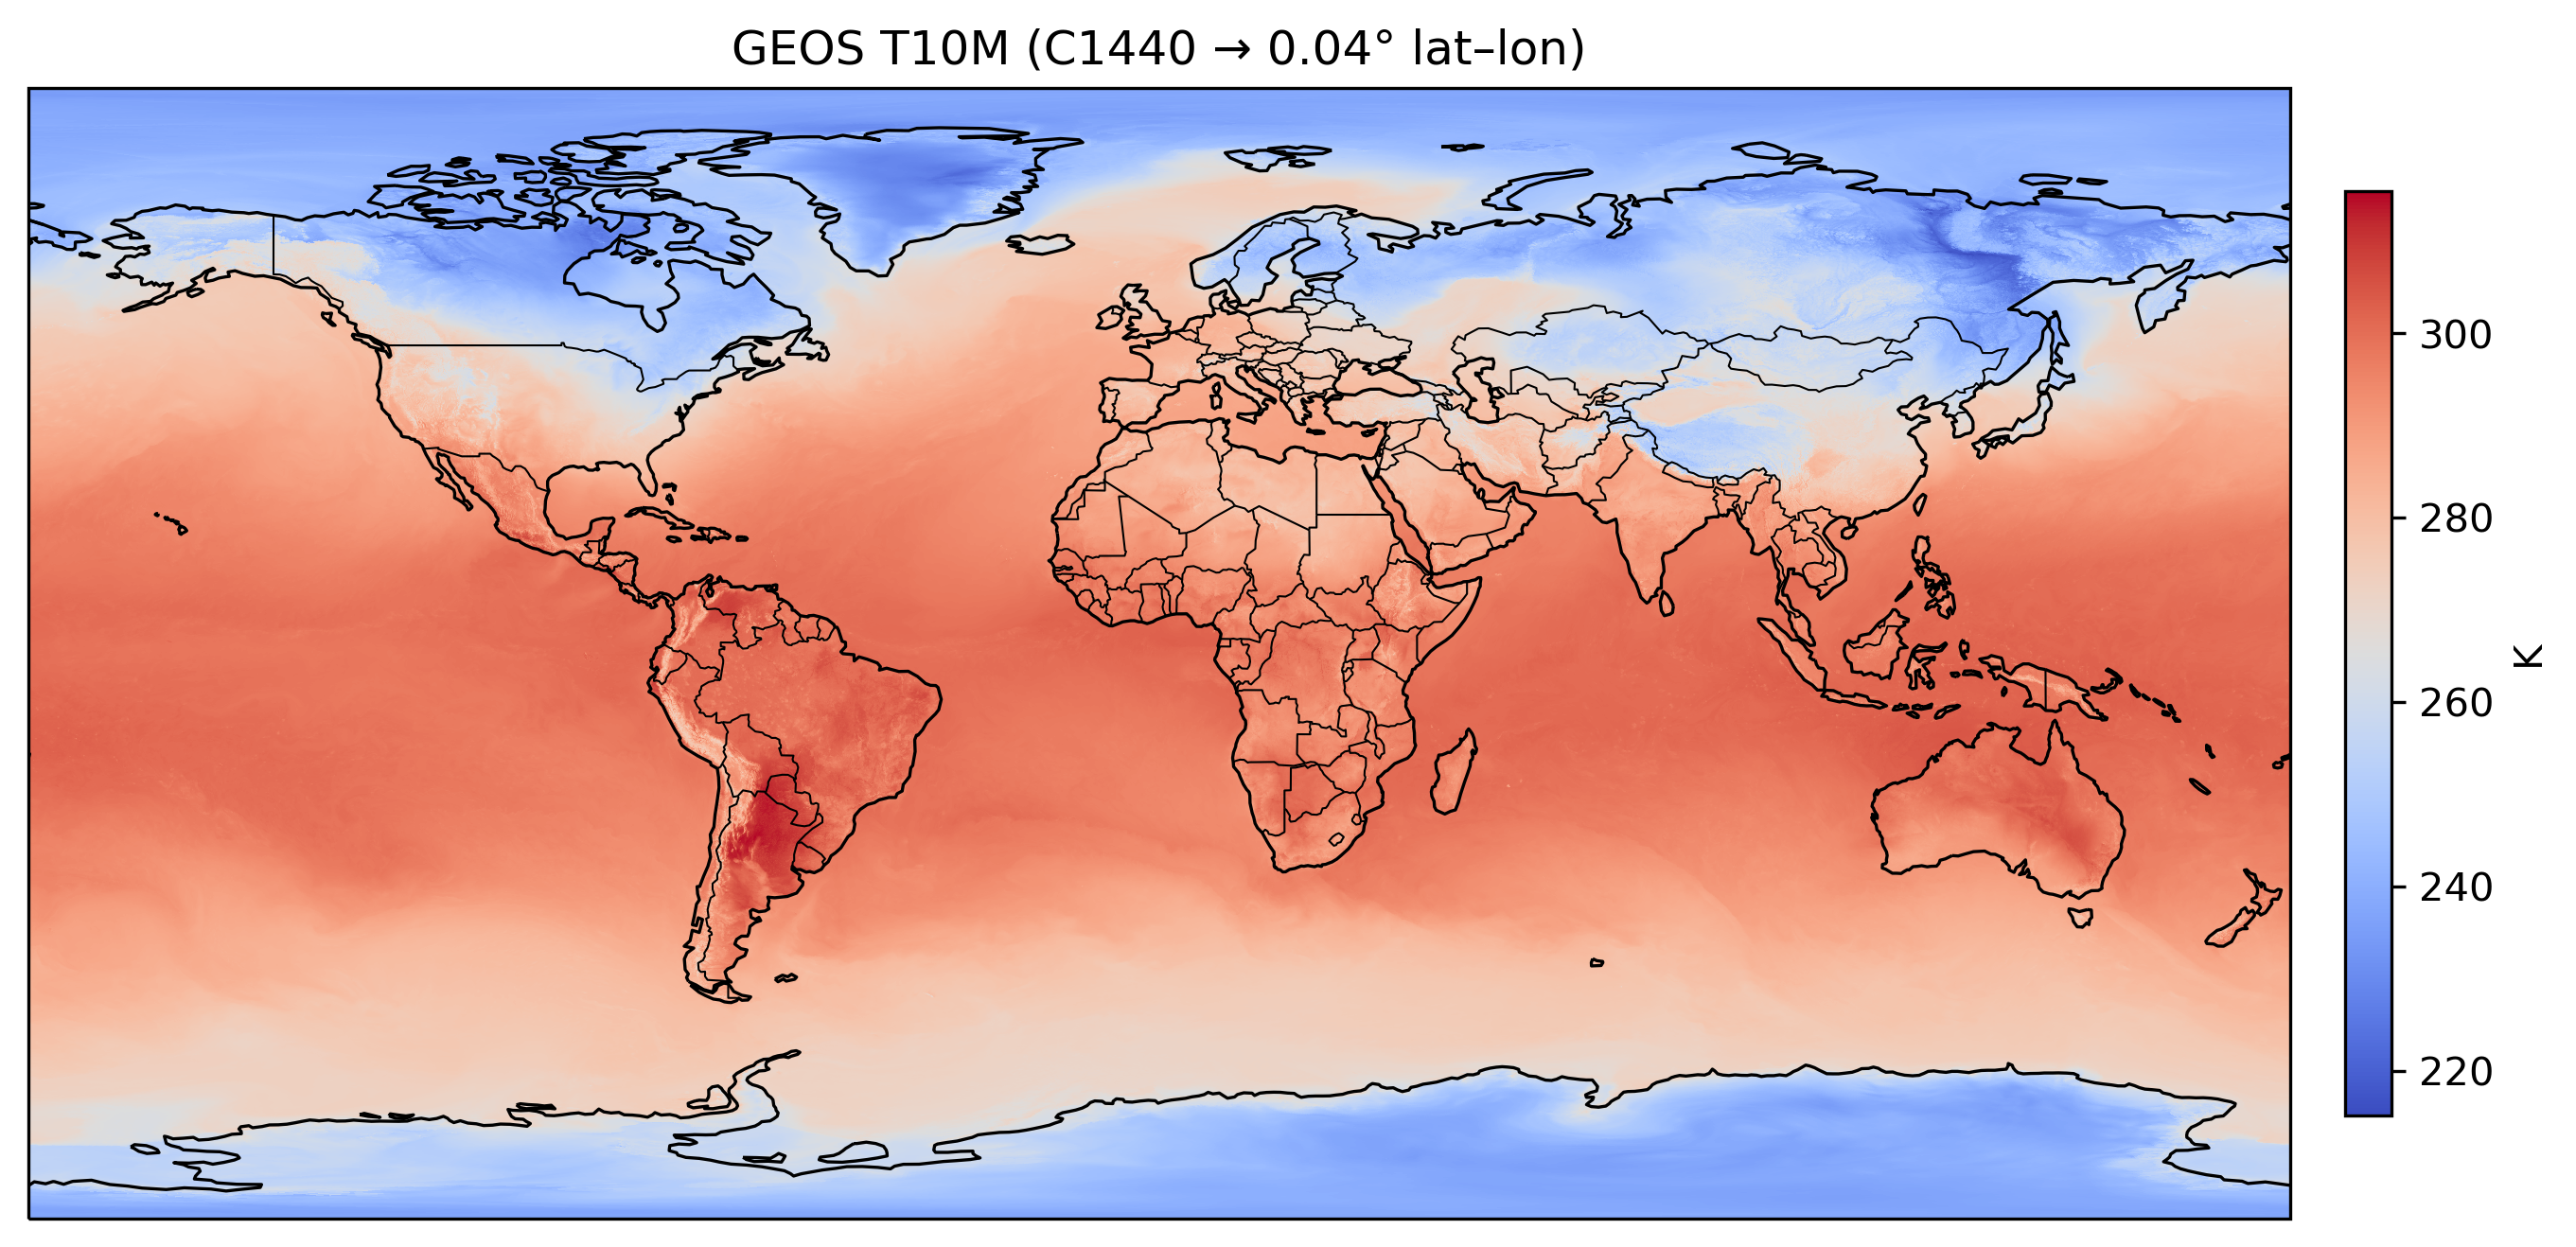

In [12]:
fig, ax = plot_latlon_cartopy(
    da_ll,
    time_index=0,
    cmap="coolwarm",
    title="GEOS T10M (C1440 → 0.04° lat–lon)",
    cbar_label="K",
)
